In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import LabelEncoder

In [2]:
house_prices = pd.read_csv('./House_Price_dataset.csv',sep=',')

In [3]:
house_prices

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4.0,2.0,3.0,yes,no,no,no,yes,2.0,yes,furnished
1,12250000,8960,4.0,4.0,4.0,yes,no,no,no,yes,3.0,no,furnished
2,12250000,9960,3.0,2.0,2.0,yes,no,yes,no,no,2.0,yes,semi-furnished
3,12215000,7500,4.0,2.0,2.0,yes,no,yes,no,yes,3.0,yes,furnished
4,11410000,7420,4.0,1.0,2.0,yes,yes,yes,no,yes,2.0,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2.0,1.0,1.0,yes,no,yes,no,no,2.0,no,unfurnished
541,1767150,2400,3.0,1.0,1.0,no,no,no,no,no,0.0,no,semi-furnished
542,1750000,3620,2.0,1.0,1.0,yes,no,no,no,no,0.0,no,unfurnished
543,1750000,2910,3.0,1.0,1.0,no,no,no,no,no,0.0,no,furnished


In [4]:
house_prices.shape

(545, 13)

In [5]:
house_prices.dtypes

price                 int64
area                  int64
bedrooms            float64
bathrooms           float64
stories             float64
mainroad             object
guestroom            object
basement             object
hotwaterheating      object
airconditioning      object
parking             float64
prefarea             object
furnishingstatus     object
dtype: object

In [6]:
house_prices.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,540.000000,540.000000,543.000000,541.000000
mean,4.766729e+06,5150.541284,2.961111,1.285185,1.804788,0.691312
std,1.870440e+06,2170.141023,0.738779,0.502464,0.869011,0.860070
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
(house_prices.isnull()).sum()

price               0
area                0
bedrooms            5
bathrooms           5
stories             2
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             4
prefarea            0
furnishingstatus    0
dtype: int64

In [8]:
(house_prices.select_dtypes(include=['int64','float64'])).median()

price        4340000.0
area            4600.0
bedrooms           3.0
bathrooms          1.0
stories            2.0
parking            0.0
dtype: float64

In [9]:
house_prices.select_dtypes(include=['int64','float64']).mean()

price        4.766729e+06
area         5.150541e+03
bedrooms     2.961111e+00
bathrooms    1.285185e+00
stories      1.804788e+00
parking      6.913124e-01
dtype: float64

In [10]:
house_prices.mode()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,3500000,6000.0,3.0,1.0,2.0,yes,no,no,no,no,0.0,no,semi-furnished
1,4200000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
house_prices=house_prices.fillna((house_prices.mode()).iloc[0])
#replace logically

In [12]:
(house_prices.isnull()).sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [13]:
x = house_prices[['area']]
y = house_prices[['price']]

In [14]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=69)


In [15]:
priceModel = LinearRegression().fit(x_train,y_train)

In [16]:
priceModel.coef_
#print intercept

array([[420.83286393]])

In [17]:
priceModel.intercept_

array([2530732.96254749])

In [18]:
y_tpred = priceModel.predict(x_train)

In [19]:
train_mse = mean_squared_error(y_train,y_tpred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train,y_tpred)
print("Mean squared error",train_mse,"\nRMSE",train_rmse,"\nR^2 Score",train_r2)

Mean squared error 2231722397483.0713 
RMSE 1493895.0423249523 
R^2 Score 0.27316451038299494


In [20]:
y_pred = priceModel.predict(x_test)

In [21]:
test_mse = mean_squared_error(y_test,y_pred)
test_rmse = ((test_mse)**0.5)
test_r2 = r2_score(y_test,y_pred)
print("Mean squared error",train_mse,"\nRMSE",train_rmse,"\nR^2 Score",train_r2)

Mean squared error 2231722397483.0713 
RMSE 1493895.0423249523 
R^2 Score 0.27316451038299494


<AxesSubplot: xlabel='area', ylabel='price'>

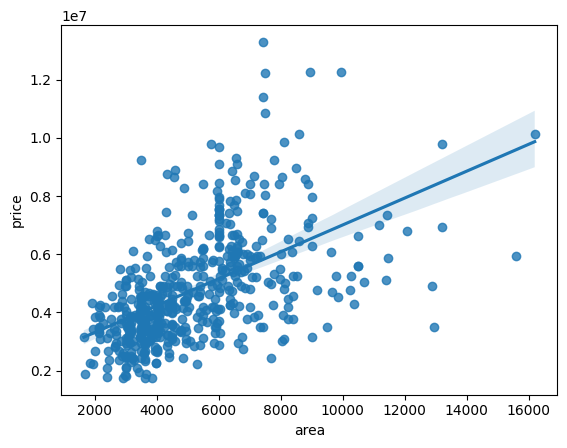

In [22]:
sns.regplot(x="area",y="price",data=house_prices)


In [23]:
inarea = int(input('Enter area to predict price '))
print("The price of your house depending on area is",priceModel.predict([[inarea]])[0][0])

Enter area to predict price 4500
The price of your house depending on area is 4424480.850246958


/home/student/.local/lib/python3.8/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [24]:
x2 = house_prices.drop(columns=['price'])
x2 = x2.replace({'yes': 1, 'no': 0})
x2 = x2.replace({'furnished': 2, 'semi-furnished': 1,'unfurnished':0})
x2.dtypes
#Note : replace will be deprecated in future versions. Use Label Encoder in sklearn library in future assignments

area                  int64
bedrooms            float64
bathrooms           float64
stories             float64
mainroad              int64
guestroom             int64
basement              int64
hotwaterheating       int64
airconditioning       int64
parking             float64
prefarea              int64
furnishingstatus      int64
dtype: object

In [25]:
x2_train,x2_test,y_train,y_test = train_test_split(x2,y,test_size=0.2,random_state=69,shuffle=True)

In [26]:
betterPriceModel = LinearRegression().fit(x2_train,y_train)

In [27]:
betterPriceModel.coef_

array([[2.29387562e+02, 8.95745595e+04, 1.04910340e+06, 4.24443705e+05,
        4.76817685e+05, 4.21570527e+05, 2.73550938e+05, 6.25000059e+05,
        8.75583863e+05, 1.86475822e+05, 6.45956734e+05, 2.13245402e+05]])

In [28]:
betterPriceModel.intercept_

array([-211156.5111847])

In [29]:
y2t_pred=betterPriceModel.predict(x2_train)

In [30]:
train2_mse = mean_squared_error(y_train,y2t_pred)
train2_rmse = np.sqrt(train2_mse)
train2_r2 = r2_score(y_train,y2t_pred)
print("Mean squared error",train2_mse,"\nRMSE",train2_rmse,"\nR^2 Score",train2_r2)

Mean squared error 929876968560.7394 
RMSE 964301.2851597469 
R^2 Score 0.6971542775706949


In [31]:
x2_test = x2_test[x2_train.columns]

y2_pred=betterPriceModel.predict(x2_test)

In [32]:
test2_mse = mean_squared_error(y_test,y2_pred)
test2_rmse = np.sqrt(test2_mse)
test2_r2 = r2_score(y_test,y2_pred)
print("Mean squared error",test2_mse,"\nRMSE",test2_rmse,"\nR^2 Score",test2_r2)

Mean squared error 2032257490178.0051 
RMSE 1425572.6884932965 
R^2 Score 0.5952245046927778


In [33]:
inarea = int(input('Enter area '))
inbedrooms = float(input('Enter number of bedrooms '))
inbathrooms = float(input('Enter number of bathrooms'))
instories = float(input('Enter number of stories(floors) '))
inmainroad = int(input('Is house on main road (yes:1/no:0)'))
inguestroom = int(input('Does house have guest room (yes:1/no:0)'))
inbasement = int(input('Does house have a basement (yes:1/no:0)'))
inhotwaterheating = int(input('Does house have hot water heating (yes:1/no:0)'))
inairconditioning = int(input('Does house have AC(yes:1/no:0'))
inparking = float(input("How many cars can parking accomodate (enter 0 if none)"))
inprefarea = int(input("Is house in preferred area (yes:1/no:0) "))
infurnishingstatus = int(input("Furnishing status of house (furnished:2,semi-furnished:1,unfurnished:0) "))
print("The price of your house depending on all factors is",betterPriceModel.predict([[inarea,inbedrooms,inbathrooms,instories,inmainroad,inguestroom,inbasement,inhotwaterheating,inairconditioning,inparking,inprefarea,infurnishingstatus]])[0,0])

Enter area 4500
Enter number of bedrooms 4
Enter number of bathrooms3
Enter number of stories(floors) 3
Is house on main road (yes:1/no:0)1
Does house have guest room (yes:1/no:0)0
Does house have a basement (yes:1/no:0)1
Does house have hot water heating (yes:1/no:0)1
Does house have AC(yes:1/no:01
How many cars can parking accomodate (enter 0 if none)2.0
Is house in preferred area (yes:1/no:0) 1
Furnishing status of house (furnished:2,semi-furnished:1,unfurnished:0) 1
The price of your house depending on all factors is 9083133.394585665


/home/student/.local/lib/python3.8/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
